In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data_sample = pd.read_csv('../data/raw/0_c2264c30c100.csv', skiprows=20)
data_sample.info()
data_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   TIME    100000 non-null  float64
 1   CH1     100000 non-null  float64
 2   CH2     100000 non-null  float64
 3   CH3     100000 non-null  float64
 4   CH4     100000 non-null  float64
dtypes: float64(5)
memory usage: 3.8 MB


,TIME,CH1,CH2,CH3,CH4
0,-5.0000,1.584,0.68,0.80,1.54
1,-4.9999,1.584,0.68,0.82,1.54
2,-4.9998,1.584,0.68,0.84,1.52
3,-4.9997,1.568,0.66,0.84,1.50
4,-4.9996,1.568,0.68,0.86,1.50


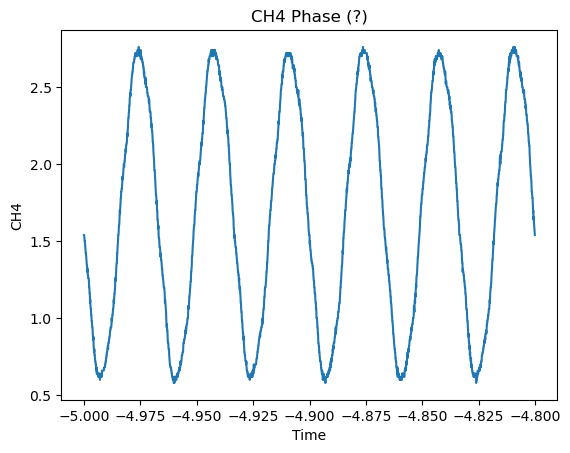

In [4]:
plt.plot(data_sample['TIME'][:2000], data_sample['CH4'][:2000])
plt.xlabel('Time')
plt.ylabel('CH4')
plt.title('CH4 Phase (?)')
plt.show()

In [5]:
def calc_mean(series: pd.Series):
    return np.mean(series)

def calc_RMS(series: pd.Series | np.ndarray):
    return np.sqrt(np.mean(series * series))

def calc_std(series: pd.Series):
    return np.std(series)

def calc_peak2peak(series: pd.Series | np.ndarray):
    return (np.max(series) - np.min(series))

# done

In [6]:
print(calc_mean(data_sample['CH1']))
print(calc_mean(data_sample['CH1']))
print(calc_RMS(data_sample['CH1']))
print(calc_std(data_sample['CH1']))
print(calc_peak2peak(data_sample['CH1']))

1.6248976000000002
1.6248976000000002
1.6287579526989269
0.1120725568292451
0.712


In [7]:
def calc_skewness(series: pd.Series | np.ndarray):
    mean = np.mean(series)
    std = np.std(series)
    z = (series - mean) ** 3
    z_mean = np.mean(z)
    return z_mean / (std ** 3)

def calc_kurtosis(series: pd.Series | np.ndarray):
    mean = np.mean(series)
    std = np.std(series)
    z = (series - mean) ** 4
    z_mean = np.mean(z)
    return z_mean / (std ** 4)

#done

In [8]:
print(calc_skewness(data_sample['CH4']))
print(calc_kurtosis(data_sample['CH3']))

-0.012005510706333163
1.5054948051436763


In [9]:
def calc_CrestFactor(series: pd.Series | np.ndarray):
    abs_max = np.max(np.abs(series))
    RMS = calc_RMS(series)
    return abs_max / RMS

def calc_FormFactor(series: pd.Series | np.ndarray):
    RMS = calc_RMS(series)
    abs_mean = np.mean(np.abs(series))
    return RMS / abs_mean

def calc_ClearenceFactor(series: pd.Series | np.ndarray):
    abs_max = np.max(np.abs(series))
    abs_sqrt_mean = np.mean(np.sqrt(np.abs(series)))
    return abs_max / (abs_sqrt_mean ** 2) 

def calc_ZeroCrossingRate(series: pd.Series | np.ndarray, threshold= 1e-6):
    signs = np.zeros_like(series)
    signs[series < threshold] = -1
    signs[series > threshold] = 1
    
    diff = np.diff(signs)
    
    return np.count_nonzero(diff) / len(series)

#done

In [10]:
print(calc_CrestFactor(data_sample['CH1']))
print(calc_FormFactor(data_sample['CH1']))
print(calc_ClearenceFactor(data_sample['CH1']))
print(calc_ZeroCrossingRate(data_sample['CH1']))

1.2082826651676104
1.0023757513697642
1.212602601565051
0.0


Let's get the sampling rate for the Fourier Transform

In [11]:
t1 = data_sample['TIME'][1]
t2 = data_sample['TIME'][2]
delta_t = t2 - t1
print(delta_t)
print(1/ delta_t)

0.00010000000000065512
9999.999999934487


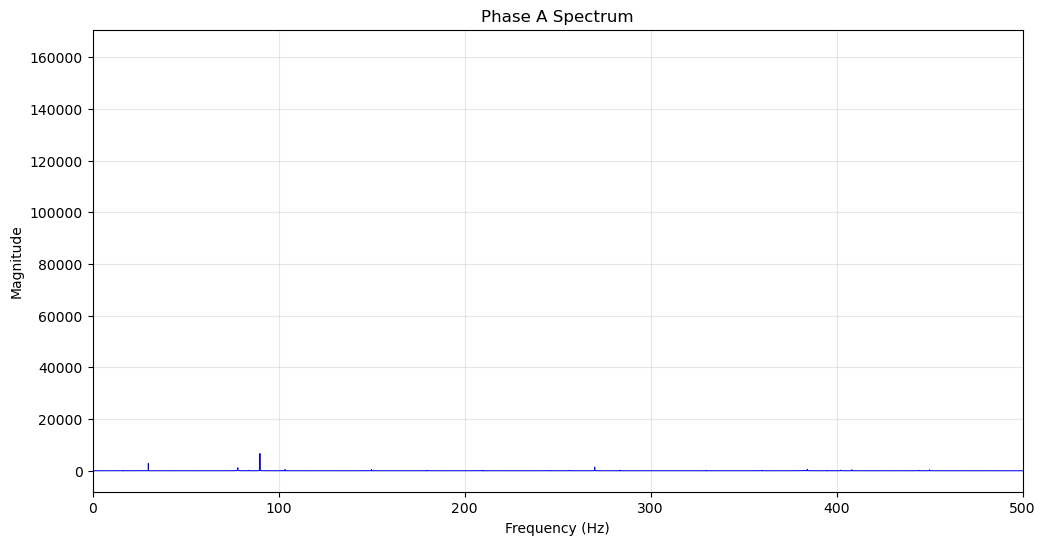

In [12]:
def plot_motor_spectrum(signal, fs, title="Frequency Spectrum"):
    # 1. Perform the Real FFT
    n = len(signal)
    magnitudes = np.abs(np.fft.rfft(signal))
    frequencies = np.fft.rfftfreq(n, d=1/fs)

    # 2. Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(frequencies, magnitudes, color='blue', lw=0.7)
    
    # 3. Focus on the important part
    # Since driving frequency is 30-60Hz, let's look at 0-500Hz 
    # to see the fundamental and the first 10 harmonics.
    plt.xlim(0, 500) 
    
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
plot_motor_spectrum(data_sample['CH1'], 10000, "Phase A Spectrum")

In [13]:
def get_fft_data(series, sampling_rate):
    n = len(series)
    # Perform the FFT
    fft_values = np.fft.rfft(series)
    # Get the magnitudes (amplitudes)
    magnitudes = np.abs(fft_values)
    # Get the frequency axis
    frequencies = np.fft.rfftfreq(n, d=1/sampling_rate)
    return frequencies, magnitudes

In [14]:
def get_fft_data(series, sampling_rate):
    n = len(series)
    
    fft_values = np.fft.rfft(series)
    
    magnitudes = np.abs(fft_values) / (n/2)
    
    frequencies = np.fft.rfftfreq(n=n, d = 1/sampling_rate)
    return frequencies, magnitudes

#done

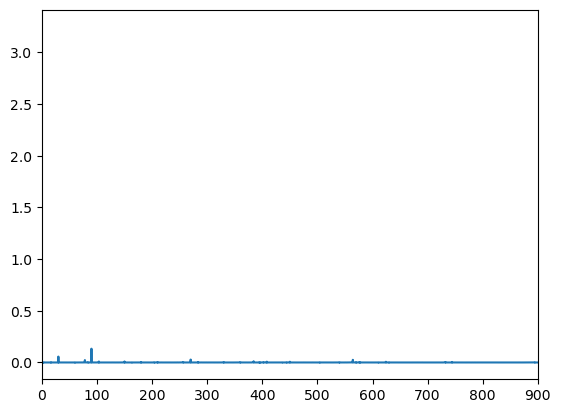

In [15]:
freq, mag = get_fft_data(data_sample['CH1'], 10000)
plt.xlim(0, 900)
plt.plot(freq, mag)

In [ ]:
def calc_FundamentalFrequency(frequencies, magnitudes):
    index_max = np.argmax(magnitudes[5:]) + 5
    return frequencies[index_max]

def get_HarmonicMagnitudes(frequencies, magnitudes, fund_freq, n_harmonics = 7) -> np.ndarray:
    harmonic_magnitudes = []
    for i in range(1, n_harmonics + 1):
        target_freq = fund_freq * i
        idx = np.argmin(np.abs(frequencies - target_freq))
        harmonic_magnitudes.append(magnitudes[idx])
        
    return np.array(harmonic_magnitudes)
    
# done

In [29]:
fund_freq = calc_FundamentalFrequency(freq, mag)
print(fund_freq)
har_freq = get_HarmonicMagnitudes(freq, mag, fund_freq)
print(har_freq)
print(np.argmax(har_freq))

89.5
[3.24979520e+00 9.87968630e-04 1.63046800e-04 1.45168240e-04
 1.83525856e-04 1.51492631e-04 5.78911451e-05]
0


In [26]:
def calc_FundamentalFrequency2(frequencies, magnitudes):
    index_max = np.argmax(magnitudes[5:]) + 5
    return frequencies[index_max]
fund_freq2 = calc_FundamentalFrequency2(freq, mag)
print(fund_freq2)

90.0


In [ ]:
def get_TotalHarmonicDistortion(harmonic_magnitudes: np.ndarray):
    m1 = harmonic_magnitudes[0]
    higher_harmnonics = harmonic_magnitudes[1:]
    
    if m1 == 0:
        return 0
    
    nominator = np.sqrt(np.sum(higher_harmnonics * higher_harmnonics))
    return (nominator / m1)

#done

In [19]:
THD = get_TotalHarmonicDistortion(fund_freq, har_freq)
print(THD)

0.036310562756839714


Pro-Tip: The "Read-Only" Mindset
In Data Science/Engineering, a good rule of thumb is: Never modify an input array inside a function. Always treat inputs as "Read-Only." If you need to change them to do a calculation, copy them first.

Does that help clarify why "local scope" doesn't protect the data inside a NumPy array? It’s a very common way to get "ghost bugs" where your results change depending on the order you call your functions!

In [20]:
a = [2,3,4,5]
print(a)
# a[2]= -99
# print(a)

def mod(array):
    array[2]= -99
    
mod(a)
print(a)

[2, 3, 4, 5]
[2, 3, -99, 5]


In [21]:
def calc_SpectralCentroid(frequencies, magnitudes):
    return np.sum(frequencies * magnitudes) / np.sum(magnitudes)

def calc_SpectralSpread(frequencies, magnitudes):
    spectral_centroid = calc_SpectralCentroid(frequencies, magnitudes)
    
    nominator = np.sum((frequencies - spectral_centroid)**2 * magnitudes)
    denominator = np.sum(magnitudes)
    
    return np.sqrt(nominator / denominator)

def calc_SidebandRatio(freq, mag, fund_freq):
    left_sideband_mag = mag[(fund_freq - 5 <= freq ) & (freq < fund_freq - 0.5)] 
    right_sideband_mag = mag[(fund_freq + 0.5 < freq) & (freq <= fund_freq + 5)]
    
    idx = np.argmin(np.abs(freq - fund_freq))
    fund_mag = mag[idx]
    
    sideband_energy = (
        (np.max(left_sideband_mag) if np.any(left_sideband_mag) else 0) +
        (np.max(right_sideband_mag)if np.any(right_sideband_mag) else 0)
    )
    
    return sideband_energy / (2 * fund_mag)
    
#done

In [22]:
spectral_centroid = calc_SpectralCentroid(freq, mag)
spectral_spread = calc_SpectralSpread(freq, mag)
sideband_ratio = calc_SidebandRatio(freq, mag, fund_freq)

print(spectral_centroid)
print(spectral_spread)
print(sideband_ratio)

1101.1630193737692
1530.274134596928
2.5354209836012056


In [23]:
def calc_PhaseImbalance(RMS_a, RMS_b, RMS_c):
    RMS = np.array([RMS_a, RMS_b, RMS_c])
    return (np.max(RMS) - np.min(RMS)) / np.mean(RMS)

def calc_ParkVectorStats(current_a, current_b, current_c):
    current_d = np.sqrt(2/3) * current_a - (1/np.sqrt(6)) * current_b - (1/np.sqrt(6)) * current_c
    current_q = (1/np.sqrt(2)) * current_b - (1/np.sqrt(2)) * current_c
    
    magnitudes = np.sqrt(current_d * current_d + current_q * current_q)
    
    mean = np.mean(magnitudes)
    std = np.std(magnitudes)
    
    return mean, std
    
def calc_FluxCurrentPhaseAngle(current_series, flux_series, fund_freq, sampling_rate):
    fft_current = np.fft.rfft(current_series)
    fft_flux = np.fft.rfft(flux_series)
    
    freqs = np.fft.rfftfreq(len(current_series), 1/sampling_rate)
    idx = np.argmin(np.abs(freqs - fund_freq))
    
    phase_current = np.angle(fft_current[idx])
    phase_flux = np.angle(fft_flux[idx])
    
    angle_diff = phase_current - phase_flux
    angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi

    return angle_diff    
    
def calc_NegativeSequenceCurrent(fft_a, fft_b, fft_c, idx_fund):
    i_a = fft_a[idx_fund]
    i_b = fft_b[idx_fund]
    i_c = fft_c[idx_fund]
    
    a = np.exp(1j * 2 * np.pi /3)
    
    I2_complex = (1/3) * (i_a + (a**2) * i_b + (a * i_c))
    
    return np.abs(I2_complex)
    
    
#done

In [24]:
phase_imbalance = calc_PhaseImbalance(
    calc_RMS(data_sample['CH1']),
    calc_RMS(data_sample['CH2']),
    calc_RMS(data_sample['CH3'])
    
    )

park_vactor_stats = calc_ParkVectorStats(
    data_sample['CH1'],
    data_sample['CH2'],
    data_sample['CH3']
)

flux_current_phase_angle = calc_FluxCurrentPhaseAngle(
    data_sample['CH1'],
    data_sample['CH4'],
    fund_freq,
    10000
)

fft_a = np.fft.rfft(data_sample['CH1'])
fft_b = np.fft.rfft(data_sample['CH2'])
fft_c = np.fft.rfft(data_sample['CH3'])

freqs = np.fft.rfftfreq(len(data_sample['CH1']), 1/10000)
idx = np.argmin(np.abs(freqs - fund_freq))

negative_sequence_current = calc_NegativeSequenceCurrent(
    fft_a=fft_a,
    fft_b=fft_b,
    fft_c=fft_c,
    idx_fund=idx)

print(phase_imbalance)
print(park_vactor_stats)
print(flux_current_phase_angle)
print(negative_sequence_current)

0.12672751597567145
(np.float64(0.7716742548937005), 0.07130208309897039)
-3.1276602591370684
15.988363787511863


In [33]:
a = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
np.split(a , [len(a) * 7 // 10, len(a) * 85 // 100])

print(a[1:])

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [ ]:
records = [
        {"name": "Alice", "age": 25, "city": "New York"},
        {"name": "Bob", "age": 30},  # Missing 'city'
        {"name": "Charlie", "age": 35, "city": "Chicago"}
    ]

new_df = pd.DataFrame(records)
# print(new_df)

print(records)

      name  age      city
0    Alice   25  New York
1      Bob   30       NaN
2  Charlie   35   Chicago
